# 🧠 WESAD Stress Recognition — Research-Grade Preprocessing Pipeline

**Standalone preprocessing notebook** — outputs saved for direct import into a model-training notebook.

---

## Pipeline Overview

| Step | Description |
|------|-------------|
| **1** | Environment setup & reproducibility seeds |
| **2** | Centralised configuration (all tunable params in one cell) |
| **3** | Data loading — WESAD `.pkl` + synthetic fallback |
| **4** | Signal quality assessment — NaN, flatline, out-of-range audit |
| **5** | Artifact removal — amplitude clipping + z-score spike removal |
| **6** | Zero-phase bandpass filtering per modality |
| **7** | Optional resampling to a common grid (for DL) |
| **8** | Sliding-window segmentation (60 s, 50% overlap) |
| **9** | Window quality gate — reject corrupted windows |
| **10** | Feature extraction — HRV, EDA, statistical, spectral, nonlinear |
| **11** | Subject-wise splitting — zero data leakage guarantee |
| **12** | Class imbalance audit |
| **13** | Normalisation — scaler fitted on training subjects only |
| **14** | Save all outputs |

---

### Quick Start
- **Synthetic demo (no data needed):** run all cells with `USE_REAL_DATA = False`.
- **WESAD:** mount Google Drive, set `USE_REAL_DATA = True` and `WESAD_PATH`.

### Research guarantees enforced throughout
- ① No data leakage — scalers fitted on training subjects only  
- ② Subject-wise group IDs preserved for LOSO / GroupKFold  
- ③ All random seeds pinned via `SEED` constant  
- ④ Every intermediate artefact saved for audit and ablation  
- ⑤ Configuration snapshot saved as JSON for reproducibility

---
## Step 1 — Environment Setup

> **Colab note:** Do **not** pin `numpy`, `scipy`, or `scikit-learn`.
> Colab ships numpy 2.x; pinning 1.x causes binary incompatibility errors.
> Only domain-specific packages are installed below.

In [ ]:
# ============================================================
# 1a. Install domain-specific packages only
# [FIX] Replaced Colab-specific !pip magic commands with
#       subprocess calls so this cell runs on both Kaggle
#       and Colab without modification.
# [FIX] imbalanced-learn>=0.13.0 required for sklearn >=1.6
#       (0.12.x imports removed private sklearn.utils API)
# ============================================================
import subprocess, sys

def _pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', *args], check=False)

_pip('install', '--upgrade', 'pip', '-q')

# antropy: install without deps to avoid numpy downgrade
_pip('install', '--no-deps', 'antropy==0.1.6', '-q')

# remaining packages
_pip('install', '-q',
     'neurokit2==0.2.7',
     'imbalanced-learn>=0.13.0',  # FIX: 0.12.x incompatible with sklearn >=1.6
     'joblib',
     'tqdm',
)

print('\u2705 Install complete.')


✅ Install complete.


In [ ]:
# ============================================================
# 1b. Verify environment — enforce numpy >= 2.0
# ============================================================
import numpy as np, pandas as pd, scipy, sklearn

print(f'numpy   : {np.__version__}  (need >=2.0)')
print(f'pandas  : {pd.__version__}')
print(f'scipy   : {scipy.__version__}')
print(f'sklearn : {sklearn.__version__}')

major = int(np.__version__.split('.')[0])
if major < 2:
    # [FIX] Downgraded from RuntimeError to warning.
    # Kaggle may ship numpy 1.x; code is compatible with 1.24+.
    import warnings as _w
    _w.warn(
        f'numpy {np.__version__} detected. numpy >=2.0 preferred; '
        '1.24+ should work. Upgrade with: pip install --upgrade numpy',
        stacklevel=2,
    )
print('✅ Environment OK')

numpy   : 2.0.2  (need >=2.0)
pandas  : 2.3.3
scipy   : 1.16.3
sklearn : 1.6.1
✅ Environment OK


In [ ]:
# ============================================================
# 1c. All imports
# ============================================================
import os, pickle, random, warnings, joblib, json
from pathlib import Path
from collections import defaultdict
from math import gcd

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.signal import butter, filtfilt, resample_poly
from scipy.interpolate import interp1d
from scipy import stats

import neurokit2 as nk
import antropy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

warnings.filterwarnings('ignore')
print('✅ All imports successful.')

✅ All imports successful.


In [ ]:
from pathlib import Path

# Find all .pkl files under the dataset mount
pkls = sorted(Path('../input').rglob('*.pkl'))
print(f"Found {len(pkls)} .pkl files:")
for p in pkls[:10]:
    print(" ", p)

Found 15 .pkl files:
  ../input/datasets/cheeseball01/websadmeow/WESAD/S10/S10.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S11/S11.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S13/S13.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S14/S14.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S15/S15.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S16/S16.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S17/S17.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S2/S2.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S3/S3.pkl
  ../input/datasets/cheeseball01/websadmeow/WESAD/S4/S4.pkl


---
## Step 2 — Configuration

All tuneable parameters live in this single cell. Every downstream step reads from these variables.

In [ ]:
# ============================================================
# 2. Centralised configuration
# ============================================================

# ── Data source ──────────────────────────────────────────────
USE_REAL_DATA = False
WESAD_PATH  = '../input/datasets/cheeseball01/websadmeow/WESAD'           # Kaggle: attach the 'wesad' dataset

# ── Sampling rates (WESAD defaults) ─────────────────────────
FS = {
    'ecg' : 700,   # ECG — chest RespiBAN sensor
    'eda' : 700,   # EDA — chest (same sensor bus as ECG)
    'bvp' : 64,    # BVP/PPG — wrist Empatica E4
    'resp': 700,   # Respiration — chest
    'temp': 4,     # Skin temperature — wrist E4
    'acc' : 32,    # Accelerometer — wrist E4
}
# Set to an int (e.g. 32) to resample everything to that rate (for DL).
# Set None to keep native rates (recommended for classical ML).
TARGET_FS = None

# ── WESAD label mapping ──────────────────────────────────────
#   0=transient/undefined  1=baseline  2=stress  3=amusement  4=meditation
VALID_LABELS = [1, 2, 3]   # discard transient (0)
BINARY_MODE  = True         # True → stress(2) vs rest(1,3)

# ── Segmentation ─────────────────────────────────────────────
WIN_SEC  = 60    # 60 s is the WESAD benchmark standard
STEP_SEC = 30    # 50% overlap

# ── Artifact / quality thresholds ────────────────────────────
MAX_NAN_FRAC = 0.05   # reject window if >5% NaN
MAX_GAP_SEC  = 2.0    # interpolate NaN gaps ≤ 2 s; leave longer
FLATLINE_WIN = 3.0    # seconds of near-zero std flagged as flatline

# Physiological plausible range per modality
PHYS_LIMITS = {
    'ecg' : (-5.0,  5.0),
    'eda' : ( 0.0, 60.0),
    'bvp' : (-1e4,  1e4),
    'resp': (-10.0, 10.0),
    'temp': (25.0,  42.0),
}

# ── Filter specs: (lo_hz, hi_hz, order); lo=None → lowpass ──
FILTER_SPECS = {
    'ecg' : (0.5,  40.0, 4),
    'eda' : (None,  5.0, 4),
    'bvp' : (0.5,   8.0, 4),
    'resp': (0.05,  0.8, 4),
    'temp': None,              # no filter — slow drift
}

# ── Synthetic fallback ────────────────────────────────────────
N_SYNTHETIC_SUBJECTS = 10
DURATION_MINUTES     = 20

# ── Held-out test subject (optional) ─────────────────────────
# Set to a subject ID (e.g. 2) to reserve one subject for final
# held-out evaluation. Set None to use all subjects in LOSO.
HELD_OUT_SUBJECT = None

# ── Output ───────────────────────────────────────────────────
# [FIX] Auto-detect environment so outputs go to the right directory.
# Kaggle → /kaggle/working  (publish as dataset 'wesad-preprocessed')
# Colab  → /content/wesad_preprocessed
import os as _os
OUTPUT_DIR = Path('/kaggle/working') if _os.path.exists('/kaggle/working') \
             else Path('/content/wesad_preprocessed')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'📁 Output dir   : {OUTPUT_DIR}')
print(f'📊 Data source  : {"WESAD (real)" if USE_REAL_DATA else "Synthetic"}')
print(f'🪟 Window/step  : {WIN_SEC}s / {STEP_SEC}s  ({100*(1-STEP_SEC/WIN_SEC):.0f}% overlap)')
print(f'🏷️  Label mode   : {"Binary (stress vs rest)" if BINARY_MODE else "Multi-class"}')

📁 Output dir   : /kaggle/working
📊 Data source  : Synthetic
🪟 Window/step  : 60s / 30s  (50% overlap)
🏷️  Label mode   : Binary (stress vs rest)


---
## Step 3 — Data Loading

### WESAD label protocol (binary mode)
| Raw label | Condition | Binary mapping |
|-----------|-----------|----------------|
| 0 | Transient / undefined | **Excluded** |
| 1 | Baseline | 0 (non-stress) |
| 2 | TSST Stress | 1 (stress) |
| 3 | Amusement | 0 (non-stress) |

Transient samples (label 0) bridge condition switches and are excluded
to avoid label noise at condition boundaries.

In [ ]:
# ============================================================
# 3a. WESAD subject loader
# ============================================================

def load_wesad_subject(pkl_path: str) -> dict | None:
    """
    Load one WESAD .pkl file (chest signals only).

    Returns a dict with:
        ecg, eda, resp, temp  — float32 arrays at their native rates
        labels                — binary (or multi-class) labels aligned to ECG (700 Hz)
        subject_id            — int
        fs                    — dict of per-modality sampling rates
    Returns None on load failure.
    """
    try:
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f, encoding='latin1')
    except Exception as e:
        print(f'  ⚠ Could not load {pkl_path}: {e}')
        return None

    chest      = data['signal']['chest']
    labels_raw = data['label'].squeeze().astype(int)

    valid_mask = np.isin(labels_raw, VALID_LABELS)
    labels     = (labels_raw == 2).astype(np.int8) if BINARY_MODE else labels_raw.astype(np.int8)

    def extract(arr):
        return arr.squeeze().astype(np.float32)[valid_mask]

    return {
        'ecg'       : extract(chest['ECG']),
        'eda'       : extract(chest['EDA']),
        'resp'      : extract(chest['Resp']),
        'temp'      : extract(chest['Temp']),
        'labels'    : labels[valid_mask],
        'subject_id': int(Path(pkl_path).stem.lstrip('S')),
        'fs'        : {'ecg': FS['ecg'], 'eda': FS['eda'],
                       'resp': FS['resp'], 'temp': FS['temp']},
    }


print('✅ WESAD loader defined.')

✅ WESAD loader defined.


In [ ]:
# ============================================================
# 3b. Synthetic data generator
# ============================================================

def generate_synthetic_subject(subject_id: int, duration_min: int = 20,
                                seed: int = 42) -> dict:
    """
    Multi-modal physiological recording mimicking WESAD structure.
    Label schedule: 30% baseline → 40% stress → 30% recovery.
    All segment durations use integer division (//) to guarantee
    int type (required by neurokit2 simulators).
    """
    np.random.seed(seed)
    dur  = duration_min * 60
    nb   = dur * 3 // 10
    ns   = dur * 4 // 10
    nr   = dur - nb - ns
    fs_e = FS['ecg']
    fs_eda_syn = 4  # use 4 Hz EDA for speed in synthetic mode

    # ECG
    ecg = np.concatenate([
        nk.ecg_simulate(duration=nb, sampling_rate=fs_e, heart_rate=65, noise=0.01,  random_state=seed),
        nk.ecg_simulate(duration=ns, sampling_rate=fs_e, heart_rate=90, noise=0.025, random_state=seed+1),
        nk.ecg_simulate(duration=nr, sampling_rate=fs_e, heart_rate=72, noise=0.015, random_state=seed+2),
    ]).astype(np.float32)

    # EDA at 4 Hz
    eda = np.concatenate([
        nk.eda_simulate(duration=nb, sampling_rate=fs_eda_syn, scr_number=3,  drift=0.01, random_state=seed),
        nk.eda_simulate(duration=ns, sampling_rate=fs_eda_syn, scr_number=14, drift=0.06, random_state=seed+1),
        nk.eda_simulate(duration=nr, sampling_rate=fs_eda_syn, scr_number=4,  drift=0.02, random_state=seed+2),
    ]).astype(np.float32)

    # Respiration at 700 Hz
    resp = np.concatenate([
        nk.rsp_simulate(duration=nb, sampling_rate=fs_e, respiratory_rate=14, random_state=seed),
        nk.rsp_simulate(duration=ns, sampling_rate=fs_e, respiratory_rate=20, random_state=seed+1),
        nk.rsp_simulate(duration=nr, sampling_rate=fs_e, respiratory_rate=16, random_state=seed+2),
    ]).astype(np.float32)

    # Skin temperature at 4 Hz (slow trend)
    n_t   = dur * 4
    nb_t, ns_t = n_t * 3 // 10, n_t * 4 // 10
    nr_t  = n_t - nb_t - ns_t
    ts    = np.linspace(0, 1, ns_t)
    tr    = np.linspace(0, 1, nr_t)
    temp  = np.concatenate([
        33.5 + 0.15 * np.random.randn(nb_t),
        33.5 - 0.7 * ts + 0.15 * np.random.randn(ns_t),
        32.8 + 0.4 * tr + 0.15 * np.random.randn(nr_t),
    ]).astype(np.float32)

    # Labels at ECG rate
    labels = np.zeros(len(ecg), dtype=np.int8)
    labels[nb * fs_e : (nb + ns) * fs_e] = 1

    return {
        'ecg': ecg, 'eda': eda, 'resp': resp, 'temp': temp,
        'labels': labels, 'subject_id': subject_id,
        'fs': {'ecg': fs_e, 'eda': fs_eda_syn, 'resp': fs_e, 'temp': 4},
    }


print('✅ Synthetic generator defined.')

✅ Synthetic generator defined.


In [ ]:
# ============================================================
# 3c. Load subjects — setup only (processing happens in Cell 10f)
# ============================================================
import gc

print('📥 Loading subjects...')
quality_log      = defaultdict(list)
all_feature_rows = []
dl_data          = []
total_wins = total_rejected = 0

if USE_REAL_DATA:
    pkl_files = sorted(Path(WESAD_PATH).glob('S*/*.pkl'))
    if not pkl_files:
        raise FileNotFoundError(
            f'No WESAD .pkl files found at: {WESAD_PATH}\n'
            '  Kaggle → WESAD_PATH = "../input/wesad/WESAD"\n'
            '  Colab  → WESAD_PATH = "/content/drive/MyDrive/WESAD"'
        )
    subject_iter = ((load_wesad_subject(str(p)), p.stem)
                for p in pkl_files)
else:
    subject_iter = ((generate_synthetic_subject(subject_id=i+1, duration_min=DURATION_MINUTES,seed=SEED+i*137), f'S{i+1}')for i in range(N_SYNTHETIC_SUBJECTS))

print(f'✅ {N_SYNTHETIC_SUBJECTS} subjects ready.')

📥 Loading subjects...
✅ 10 subjects ready.


---
## Step 4 — Signal Quality Assessment

Audit each raw signal for missing values, flatlines, and physiologically impossible amplitudes.
**No data is discarded here** — we generate a quality report; rejection happens at window level in Step 9.

In [ ]:
# ============================================================
# 4. Signal Quality Assessment
# ============================================================

def signal_quality_report(signal, name, fs, phys_lo=None, phys_hi=None) -> dict:
    n = len(signal)
    nan_mask = np.isnan(signal)
    inf_mask = np.isinf(signal)
    clean    = signal[~nan_mask & ~inf_mask]

    out_of_range = 0.0
    if phys_lo is not None and len(clean):
        out_of_range = float(((clean < phys_lo) | (clean > phys_hi)).mean())

    # Flatline: sliding window zero-std detection
    flat_win = int(FLATLINE_WIN * fs)
    flat_count = 0
    if flat_win > 1 and len(clean) >= flat_win:
        for i in range(0, len(clean) - flat_win, flat_win // 2):
            if np.std(clean[i:i+flat_win]) < 1e-6:
                flat_count += flat_win

    return {
        'name'             : name,
        'n_samples'        : n,
        'nan_frac'         : float(nan_mask.mean()),
        'inf_frac'         : float(inf_mask.mean()),
        'phys_outlier_frac': out_of_range,
        'flatline_frac'    : flat_count / max(len(clean), 1),
        'mean'             : float(np.nanmean(signal)),
        'std'              : float(np.nanstd(signal)),
        'min'              : float(np.nanmin(signal)),
        'max'              : float(np.nanmax(signal)),
    }

# ── Execution block disabled: now called inside
# ── process_one_subject() in Cell 3c above. ────
# quality_log = defaultdict(list)
# for subj in subjects_raw:
#     sid = subj['subject_id']
#     for mod in ['ecg','eda','resp','temp']:
#         arr = subj.get(mod)
#         if arr is None: continue
#         fs_mod = subj['fs'].get(mod, 1)
#         pr     = PHYS_LIMITS.get(mod, (None, None))
#         r = signal_quality_report(arr, f'S{sid}_{mod}', fs_mod, pr[0], pr[1])
#         r['subject_id'] = sid
#         quality_log[mod].append(r)

# print('📋 Signal Quality Summary (across subjects)')
# print('='*60)
# for mod, reps in quality_log.items():
#     nan_m  = np.mean([r['nan_frac']          for r in reps])*100
#     out_m  = np.mean([r['phys_outlier_frac'] for r in reps])*100
#     flat_m = np.mean([r['flatline_frac']     for r in reps])*100
#     print(f'  {mod.upper():6s}: NaN={nan_m:.2f}%  OutOfRange={out_m:.2f}%  Flatline={flat_m:.2f}%')

# pd.DataFrame([r for rlist in quality_log.values() for r in rlist]).to_csv(
#     OUTPUT_DIR / 'signal_quality_report.csv', index=False)
# print('\n✅ Quality report saved.')

---
## Step 5 — Artifact Removal (Signal Level)

Three strategies applied in sequence:
1. **Amplitude clipping** — values outside physiological range → NaN
2. **Z-score spike removal** — samples > 5σ from rolling median → NaN (for ECG, EDA, BVP)
3. **NaN interpolation** — short gaps (≤ `MAX_GAP_SEC`) linearly interpolated; longer gaps left as NaN for window-level rejection

> We convert artifacts to NaN rather than discarding outright, so downstream segmentation can apply window-level rejection with full context.

In [ ]:
# ============================================================
# 5. Artifact Removal
# ============================================================

def interpolate_nans(signal, fs, max_gap_sec=MAX_GAP_SEC):
    nan_mask = np.isnan(signal)
    if not nan_mask.any():
        return signal.copy(), False
    max_gap  = int(max_gap_sec * fs)
    changes  = np.diff(nan_mask.astype(int), prepend=0, append=0)
    starts   = np.where(changes ==  1)[0]
    ends     = np.where(changes == -1)[0]
    out      = signal.copy()
    has_long = False
    for s, e in zip(starts, ends):
        if e - s <= max_gap:
            xl = max(s-1, 0); xr = min(e, len(signal)-1)
            if xr > xl:
                out[s:e] = np.interp(np.arange(s,e), [xl,xr], [signal[xl],signal[xr]])
        else:
            has_long = True
    return out, has_long


def clip_to_phys_range(signal, lo, hi):
    out = signal.copy().astype(np.float32)
    out[(out < lo) | (out > hi)] = np.nan
    return out


def zscore_spike_removal(signal, fs, window_sec=3.0, threshold=5.0):
    """
    Vectorised rolling-MAD spike removal.
    Replaces the original O(n²) per-sample loop with a strided
    rolling-window median/MAD, which is ~100x faster on 700 Hz signals.
    """
    out     = signal.copy().astype(np.float32)
    n       = len(signal)
    win     = max(int(window_sec * fs), 3)
    half    = win // 2
    # Pad signal to handle borders
    padded  = np.pad(signal.astype(np.float64), (half, half), mode='edge')
    # Build rolling windows via stride_tricks
    shape   = (n, win)
    strides = (padded.strides[0], padded.strides[0])
    windows = np.lib.stride_tricks.as_strided(padded, shape=shape, strides=strides)
    med     = np.nanmedian(windows, axis=1)
    mad     = np.nanmedian(np.abs(windows - med[:, None]), axis=1) * 1.4826
    # Avoid division by near-zero MAD
    valid   = mad > 1e-8
    spike   = valid & (np.abs(signal.astype(np.float64) - med) > threshold * mad)
    out[spike] = np.nan
    return out


def artifact_removal_pipeline(signal, modality, fs):
    phys = PHYS_LIMITS.get(modality)
    if phys:
        signal = clip_to_phys_range(signal, phys[0], phys[1])
    if modality in ('ecg','eda','bvp'):
        signal = zscore_spike_removal(signal, fs)
    signal, _ = interpolate_nans(signal, fs)
    return signal

# ── Execution block disabled: now called inside
# ── process_one_subject() in Cell 3c above. ────
# print('🔧 Applying artifact removal...')
# subjects_clean = []
# for subj in tqdm(subjects_raw, desc='Artifact removal'):
#     c = dict(subj)
#     for mod in ['ecg','eda','resp','temp']:
#         arr = subj.get(mod)
#         if arr is None: continue
#         c[mod] = artifact_removal_pipeline(arr, mod, subj['fs'].get(mod,1))
#     subjects_clean.append(c)
# print('✅ Artifact removal complete.')

---
## Step 6 — Zero-Phase Bandpass Filtering

**All filters use `scipy.signal.filtfilt` (zero-phase, bidirectional).**

Using `lfilter` instead introduces group delay that corrupts R-peak timing in ECG — even a 1-sample shift
at 700 Hz = 1.4 ms systematic error in RMSSD, a primary stress biomarker.

| Signal | Type | Passband | Rationale |
|--------|------|----------|-----------|
| ECG | Bandpass | 0.5–40 Hz | Remove baseline wander and EMG/powerline noise |
| EDA | Lowpass | 0–5 Hz | EDA physiological bandwidth ≤ 3 Hz |
| BVP/PPG | Bandpass | 0.5–8 Hz | Cardiac band; removes motion DC drift |
| Resp | Bandpass | 0.05–0.8 Hz | 3–48 breaths/min |
| Temp | None | — | Inherently slow; any filter would distort |

In [ ]:
# ============================================================
# 6. Zero-Phase Butterworth Filtering
# ============================================================

def _min_filtfilt_len(order):
    """filtfilt needs signal length > 3 * (filter order + 1)."""
    return 3 * (order + 1) + 1


def bandpass_filter(signal, fs, lo, hi, order=4):
    if len(signal) < _min_filtfilt_len(order):
        return signal
    nyq  = 0.5 * fs
    low  = max(lo/nyq, 1e-6)
    high = min(hi/nyq, 0.9999)
    if low >= high: return signal
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal).astype(np.float32)


def lowpass_filter(signal, fs, cutoff, order=4):
    if len(signal) < _min_filtfilt_len(order):
        return signal
    nyq = 0.5 * fs
    b, a = butter(order, min(cutoff/nyq, 0.9999), btype='low')
    return filtfilt(b, a, signal).astype(np.float32)


def filter_subject(subj):
    out = dict(subj)
    for mod, spec in FILTER_SPECS.items():
        arr = subj.get(mod)
        if arr is None or spec is None: continue
        fs_mod = subj['fs'].get(mod, 1)
        lo, hi, order = spec
        nan_mask   = np.isnan(arr)
        arr_filled = arr.copy()
        arr_filled[nan_mask] = 0.0
        filtered = lowpass_filter(arr_filled, fs_mod, hi, order) if lo is None \
                   else bandpass_filter(arr_filled, fs_mod, lo, hi, order)
        filtered[nan_mask] = np.nan
        out[mod] = filtered
    return out

# ── Execution block disabled: now called inside
# ── process_one_subject() in Cell 3c above. ────
# print('🔧 Filtering signals...')
# subjects_filtered = [filter_subject(s) for s in tqdm(subjects_clean, desc='Filtering')]
# print('✅ Filtering complete.')

# # Visualise filtering on Subject 1 ECG
# s0r = subjects_clean[0]; s0f = subjects_filtered[0]
# n_plot = min(FS['ecg']*5, len(s0r['ecg']))
# t      = np.arange(n_plot) / FS['ecg']
# fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
# axes[0].plot(t, s0r['ecg'][:n_plot], lw=0.6, color='gray',      label='Raw')
# axes[1].plot(t, s0f['ecg'][:n_plot], lw=0.6, color='steelblue', label='Filtered (0.5–40 Hz)')
# for ax in axes:
#     ax.set_ylabel('ECG (a.u.)'); ax.legend(loc='upper right'); ax.grid(alpha=0.3)
# axes[1].set_xlabel('Time (s)')
# plt.suptitle('ECG: Raw vs Zero-Phase Filtered (Subject 1, first 5 s)', fontsize=12, fontweight='bold')
# plt.tight_layout()
# plt.savefig(OUTPUT_DIR/'filter_comparison_ecg.png', dpi=120, bbox_inches='tight')
# plt.show()
# print('📊 Filter comparison plot saved.')

---
## Step 7 — Resampling & Label Alignment (Optional)

Set `TARGET_FS` in Step 2 to resample all signals to a common rate.
This is required for multivariate deep learning but **not** needed for classical ML
(each modality is segmented independently at its native rate).

In [ ]:
# ============================================================
# 7. Optional resampling to common grid
# ============================================================

def resample_signal(signal, orig_fs, target_fs):
    g  = gcd(int(orig_fs), int(target_fs))
    up = target_fs // g
    dn = orig_fs  // g
    nan_mask = np.isnan(signal)
    filled   = signal.copy(); filled[nan_mask] = 0.0
    rs       = resample_poly(filled, up, dn).astype(np.float32)
    if nan_mask.any():
        idx = np.clip(np.round(np.linspace(0, len(nan_mask)-1, len(rs))).astype(int), 0, len(nan_mask)-1)
        rs[nan_mask[idx]] = np.nan
    return rs


def align_labels(labels, orig_len, new_len):
    idx = np.clip(np.round(np.linspace(0, orig_len-1, new_len)).astype(int), 0, orig_len-1)
    return labels[idx]

# ── Execution block disabled: now called inside
# ── process_one_subject() in Cell 3c above. ────
# if TARGET_FS is not None:
#     print(f'🔧 Resampling all signals to {TARGET_FS} Hz...')
#     subjects_resampled = []
#     for subj in tqdm(subjects_filtered, desc='Resampling'):
#         out  = dict(subj)
#         orig = subj.get('ecg', np.array([]))
#         for mod in ['ecg','eda','resp','temp']:
#             arr = subj.get(mod)
#             if arr is None: continue
#             fm  = subj['fs'].get(mod, TARGET_FS)
#             if fm != TARGET_FS:
#                 out[mod]      = resample_signal(arr, fm, TARGET_FS)
#                 out['fs'][mod] = TARGET_FS
#         new_len       = len(out.get('ecg', orig))
#         out['labels'] = align_labels(subj['labels'], len(orig), new_len)
#         subjects_resampled.append(out)
#     subjects_to_segment = subjects_resampled
#     print('✅ Resampling complete.')
# else:
#     print('ℹ️  TARGET_FS=None — skipping resampling. '
#           'Modalities will be segmented at native rates.')
#     subjects_to_segment = subjects_filtered

---
## Step 8 — Sliding-Window Segmentation

**Parameters:** `WIN_SEC=60`, `STEP_SEC=30` (50% overlap).

- 60-second windows are long enough for reliable HRV frequency-domain features (LF/HF power).
- 50% overlap doubles the dataset size without introducing look-ahead bias.
- Labels assigned by majority vote within each window.

In [ ]:
# ============================================================
# 8. Sliding-Window Segmentation
# ============================================================

def sliding_windows(signal, labels, fs, win_sec=WIN_SEC, step_sec=STEP_SEC):
    """
    Segment a 1-D signal into overlapping windows.

    Returns
    -------
    windows       : (n_windows, win_len)  float32
    window_labels : (n_windows,)          int8   — majority-vote label
    reject_flags  : (n_windows,)          bool   — True = high NaN
    starts        : (n_windows,)          int    — sample index of each window start
    """
    win_len  = int(win_sec  * fs)
    step_len = int(step_sec * fs)
    n        = len(signal)
    all_windows, all_labels, all_rejects, all_starts = [], [], [], []

    for start in range(0, n - win_len + 1, step_len):
        seg     = signal[start:start+win_len]
        lbl_seg = labels[start:start+win_len]
        nan_frac = float(np.isnan(seg).mean())
        win_lbl  = 1 if float(lbl_seg.mean()) >= 0.5 else 0
        all_windows.append(seg.copy())
        all_labels.append(win_lbl)
        all_rejects.append(nan_frac > MAX_NAN_FRAC)
        all_starts.append(start)

    if not all_windows:
        empty = np.empty((0, win_len), dtype=np.float32)
        return empty, np.empty(0,np.int8), np.empty(0,bool), np.empty(0,int)

    return (
        np.stack(all_windows).astype(np.float32),
        np.array(all_labels,  dtype=np.int8),
        np.array(all_rejects, dtype=bool),
        np.array(all_starts,  dtype=int),
    )


print(f'✅ Segmentation defined: {WIN_SEC}s window / {STEP_SEC}s step  '
      f'({100*(1-STEP_SEC/WIN_SEC):.0f}% overlap)')

✅ Segmentation defined: 60s window / 30s step  (50% overlap)


---
## Step 9 — Window Quality Gate

A window is **rejected** if any of the following hold:

| Criterion | Threshold | Rationale |
|-----------|-----------|----------|
| NaN fraction | > `MAX_NAN_FRAC` (5%) | Too corrupt for reliable feature extraction |
| Near-zero std | std < 1e-4 | Flatline — sensor disconnected or saturated |

Windows at condition boundaries (10–90% stress samples) are **flagged but not rejected by default**;
they can be optionally excluded in ablation experiments using the `is_boundary` column.

In [ ]:
# ============================================================
# 9. Window Quality Gate + Master Segmentation Loop
# ============================================================

def quality_gate(window, label_seg, min_std=1e-4):
    clean       = window[~np.isnan(window)]
    nan_frac    = float(np.isnan(window).mean())
    std_val     = float(np.std(clean)) if len(clean) > 1 else 0.0
    stress_frac = float(label_seg.mean())
    is_boundary = 0.1 < stress_frac < 0.9
    reject = nan_frac > MAX_NAN_FRAC or std_val < min_std
    return {'reject': reject, 'is_boundary': is_boundary,
            'nan_frac': nan_frac, 'std_val': std_val}

# ── Execution block disabled: now called inside
# ── process_one_subject() in Cell 3c above. ────
# print('🔪 Segmenting and applying quality gate...')
# segmented           = []
# total_wins = total_rejected = 0

# for subj in tqdm(subjects_to_segment, desc='Segmenting'):
#     sid    = subj['subject_id']
#     labels = subj['labels']
#     ecg    = subj.get('ecg')
#     if ecg is None: continue
#     fs_ecg = subj['fs']['ecg']

#     # Align labels to ECG length
#     if len(labels) != len(ecg):
#         labels = align_labels(labels, len(labels), len(ecg))

#     wins, win_lbls, _, starts = sliding_windows(ecg, labels, fs_ecg)
#     win_len = int(WIN_SEC * fs_ecg)

#     qg_flags = []
#     for w_idx in range(len(wins)):
#         seg_lbl = labels[starts[w_idx]:starts[w_idx]+win_len]
#         qg_flags.append(quality_gate(wins[w_idx], seg_lbl))

#     valid_mask  = np.array([not q['reject'] for q in qg_flags])
#     total_wins     += len(wins)
#     total_rejected += (~valid_mask).sum()

#     # Segment secondary modalities at native rates
#     def seg_mod(mod):
#         arr = subj.get(mod)
#         if arr is None: return np.empty((0,0), np.float32)
#         fs_m  = subj['fs'].get(mod, 1)
#         lbl_m = align_labels(subj['labels'], len(subj['labels']), len(arr))
#         w, _, _, _ = sliding_windows(arr, lbl_m, fs_m)
#         return w

#     segmented.append({
#         'subject_id'  : sid,
#         'ecg_windows' : wins,
#         'eda_windows' : seg_mod('eda'),
#         'temp_windows': seg_mod('temp'),
#         'resp_windows': seg_mod('resp'),
#         'labels'      : win_lbls,
#         'valid_mask'  : valid_mask,
#         'qg_flags'    : qg_flags,
#         'fs_ecg'      : fs_ecg,
#         'fs_eda'      : subj['fs'].get('eda', 4),
#         'fs_temp'     : subj['fs'].get('temp', 4),
#         'fs_resp'     : subj['fs'].get('resp', 700),
#     })

# print(f'\n✅ Segmentation + quality gate complete.')
# print(f'   Total windows   : {total_wins:,}')
# print(f'   Rejected        : {total_rejected:,} ({100*total_rejected/max(total_wins,1):.1f}%)')
# print(f'   Retained        : {total_wins - total_rejected:,}')

---
## Step 10 — Feature Extraction

| Feature family | Modality | Key features |
|----------------|----------|--------------|
| Time-domain HRV | ECG | RMSSD, pNN50, SDNN, MeanNN, CVNN |
| Frequency-domain HRV | ECG | LF, HF, LF/HF, VLF, TP, normalised LF/HF |
| Nonlinear HRV | ECG | SD1, SD2, DFA α1, SampEn, ApEn |
| EDA decomposition | EDA | Tonic SCL (mean, slope), phasic SCR count, amplitude |
| Statistical | All | Mean, std, skew, kurtosis, IQR, range, RMS |
| Spectral | ECG/EDA | Entropy, centroid, bandwidth, peak frequency |
| Nonlinear | ECG/EDA | SampEn, permutation entropy, SVD entropy, DFA |
| Respiration | Resp | Rate mean/std, inter-breath interval |
| Temperature | Temp | Mean, slope, variability |

In [ ]:
# ============================================================
# 10a–e. Feature extraction functions
# ============================================================

def extract_hrv(ecg_win, fs):
    feats = {}
    try:
        clean = nk.ecg_clean(ecg_win, sampling_rate=int(fs))
        signals, info = nk.ecg_process(clean, sampling_rate=int(fs))
        # R-peak indices live in the signals DataFrame, not in info
        rp = np.where(signals['ECG_R_Peaks'].values == 1)[0]
        if len(rp) < 4: return feats
        # hrv_* accept the processed signals DataFrame directly
        td = nk.hrv_time(signals,      sampling_rate=int(fs), show=False)
        fd = nk.hrv_frequency(signals, sampling_rate=int(fs), show=False)
        nl = nk.hrv_nonlinear(signals, sampling_rate=int(fs), show=False)
        for col in ['HRV_RMSSD','HRV_pNN50','HRV_SDNN','HRV_MeanNN','HRV_SDSD','HRV_CVNN']:
            v = td.get(col); feats[f'hrv_td_{col}'] = float(v.iloc[0]) if v is not None else np.nan
        for col in ['HRV_LF','HRV_HF','HRV_LFHF','HRV_VLF','HRV_TP','HRV_LFn','HRV_HFn']:
            v = fd.get(col); feats[f'hrv_fd_{col}'] = float(v.iloc[0]) if v is not None else np.nan
        for col in ['HRV_SD1','HRV_SD2','HRV_SD1SD2','HRV_DFA_alpha1','HRV_SampEn','HRV_ApEn']:
            v = nl.get(col); feats[f'hrv_nl_{col}'] = float(v.iloc[0]) if v is not None else np.nan
    except Exception: pass
    return feats


def extract_eda_feats(eda_win, fs):
    feats = {}
    try:
        signals, info = nk.eda_process(eda_win, sampling_rate=int(fs))
        tonic  = signals['EDA_Tonic'].values
        phasic = signals['EDA_Phasic'].values
        feats['eda_tonic_mean']    = float(np.nanmean(tonic))
        feats['eda_tonic_std']     = float(np.nanstd(tonic))
        feats['eda_tonic_slope']   = float(np.polyfit(np.arange(len(tonic)), tonic, 1)[0])
        feats['eda_phasic_mean']   = float(np.nanmean(phasic))
        feats['eda_phasic_max']    = float(np.nanmax(phasic))
        feats['eda_phasic_energy'] = float(np.nansum(phasic**2))
        scr = info.get('SCR_Peaks',[])
        feats['eda_scr_count'] = int(len(scr))
        amp = info.get('SCR_Amplitude',[])
        if hasattr(amp,'__len__') and len(amp):
            feats['eda_scr_amp_mean'] = float(np.nanmean(amp))
            feats['eda_scr_amp_max']  = float(np.nanmax(amp))
        else:
            feats['eda_scr_amp_mean'] = feats['eda_scr_amp_max'] = 0.0
        feats['eda_skew']     = float(stats.skew(eda_win))
        feats['eda_kurtosis'] = float(stats.kurtosis(eda_win))
    except Exception: pass
    return feats


def extract_stat(seg, prefix):
    c = seg[~np.isnan(seg)]
    if len(c) < 4: return {}
    return {
        f'{prefix}_mean' : float(np.mean(c)),
        f'{prefix}_std'  : float(np.std(c)),
        f'{prefix}_skew' : float(stats.skew(c)),
        f'{prefix}_kurt' : float(stats.kurtosis(c)),
        f'{prefix}_p25'  : float(np.percentile(c, 25)),
        f'{prefix}_p75'  : float(np.percentile(c, 75)),
        f'{prefix}_iqr'  : float(np.percentile(c,75) - np.percentile(c,25)),
        f'{prefix}_range': float(c.max()-c.min()),
        f'{prefix}_rms'  : float(np.sqrt(np.mean(c**2))),
    }


def extract_spectral(seg, fs, prefix):
    feats = {}
    try:
        c = seg[~np.isnan(seg)]
        if len(c) < 8: return feats
        fft = np.abs(np.fft.rfft(c))
        frq = np.fft.rfftfreq(len(c), d=1.0/fs)
        tot = np.sum(fft**2)
        pn  = fft**2 / (tot + 1e-12)
        feats[f'{prefix}_spec_entropy']  = float(-np.sum(pn * np.log2(pn+1e-12)))
        cen = float(np.sum(frq*fft)/(np.sum(fft)+1e-12))
        feats[f'{prefix}_spec_centroid'] = cen
        feats[f'{prefix}_spec_bw']       = float(np.sqrt(np.sum((frq-cen)**2*fft)/(np.sum(fft)+1e-12)))
        feats[f'{prefix}_peak_freq']     = float(frq[np.argmax(fft)])
        feats[f'{prefix}_total_power']   = float(tot)
    except Exception: pass
    return feats


def extract_nonlinear(seg, prefix, max_len=2000):
    feats = {}
    try:
        c = seg[~np.isnan(seg)][:max_len].astype(np.float64)
        if len(c) < 10: return feats
        feats[f'{prefix}_sampen']   = float(antropy.sample_entropy(c))
        feats[f'{prefix}_perm_ent'] = float(antropy.perm_entropy(c, normalize=True))
        feats[f'{prefix}_svd_ent']  = float(antropy.svd_entropy(c, normalize=True))
        feats[f'{prefix}_dfa']      = float(antropy.detrended_fluctuation(c))
    except Exception: pass
    return feats


def extract_resp_feats(resp_win, fs):
    feats = {}
    try:
        signals, info = nk.rsp_process(resp_win, sampling_rate=int(fs))
        rr = signals['RSP_Rate'].values
        feats['resp_rate_mean'] = float(np.nanmean(rr))
        feats['resp_rate_std']  = float(np.nanstd(rr))
        # RSP_Peaks is a boolean column in signals, not a list in info
        peaks = np.where(signals['RSP_Peaks'].values == 1)[0]
        if len(peaks) > 1:
            ibi = np.diff(peaks) / fs
            feats['resp_ibi_mean'] = float(np.mean(ibi))
            feats['resp_ibi_std']  = float(np.std(ibi))
    except Exception: pass
    return feats


print('✅ Feature extractors defined.')

✅ Feature extractors defined.


In [ ]:
# ============================================================
# 10f. Define process_one_subject() + run streaming loop
# All helper functions are defined above — safe to call them here
# ============================================================

def process_one_subject(subj_raw):
    # ── Step 4: quality report ────────────────────────────────
    for mod in ['ecg','eda','resp','temp']:
        arr = subj_raw.get(mod)
        if arr is None: continue
        fs_mod = subj_raw['fs'].get(mod, 1)
        pr     = PHYS_LIMITS.get(mod, (None, None))
        r = signal_quality_report(arr, f'S{subj_raw["subject_id"]}_{mod}',
                                   fs_mod, pr[0], pr[1])
        r['subject_id'] = subj_raw['subject_id']
        quality_log[mod].append(r)

    # ── Step 5: artifact removal ──────────────────────────────
    subj_clean = dict(subj_raw)
    for mod in ['ecg','eda','resp','temp']:
        arr = subj_raw.get(mod)
        if arr is None: continue
        subj_clean[mod] = artifact_removal_pipeline(arr, mod,
                              subj_raw['fs'].get(mod, 1))

    # ── Step 6: filtering ─────────────────────────────────────
    subj_filt = filter_subject(subj_clean)
    del subj_clean; gc.collect()

    # ── Step 7: free filtered raw signals after resampling ───
    if TARGET_FS is not None:
        out  = dict(subj_filt)
        orig = subj_filt.get('ecg', np.array([]))
        for mod in ['ecg','eda','resp','temp']:
            arr = subj_filt.get(mod)
            if arr is None: continue
            fm = subj_filt['fs'].get(mod, TARGET_FS)
            if fm != TARGET_FS:
                out[mod]       = resample_signal(arr, fm, TARGET_FS)
                out['fs'][mod] = TARGET_FS
        out['labels'] = align_labels(subj_filt['labels'],
                                      len(orig), len(out['ecg']))
        del subj_filt; gc.collect()   # FIX: free pre-resample copy
        subj_filt = out

    # ── Steps 8+9: segmentation + quality gate ────────────────
    sid    = subj_filt['subject_id']
    labels = subj_filt['labels']
    ecg    = subj_filt.get('ecg')
    if ecg is None:
        return [], None, 0, 0
    fs_ecg = subj_filt['fs']['ecg']
    if len(labels) != len(ecg):
        labels = align_labels(labels, len(labels), len(ecg))

    wins, win_lbls, _, starts = sliding_windows(ecg, labels, fs_ecg)

    # FIX: free the full-length signal arrays — only windows needed now
    del ecg; gc.collect()

    win_len    = int(WIN_SEC * fs_ecg)
    qg_flags   = [quality_gate(wins[w], labels[starts[w]:starts[w]+win_len])
                  for w in range(len(wins))]
    valid_mask = np.array([not q['reject'] for q in qg_flags])

    def seg_mod(mod):
        arr = subj_filt.get(mod)
        if arr is None: return np.empty((0, 0), np.float32)
        fs_m  = subj_filt['fs'].get(mod, 1)
        lbl_m = align_labels(subj_filt['labels'], len(subj_filt['labels']), len(arr))
        w, _, _, _ = sliding_windows(arr, lbl_m, fs_m)
        return w

    eda_w  = seg_mod('eda');  fs_eda = subj_filt['fs'].get('eda',  4)
    tmp_w  = seg_mod('temp'); fs_tmp = subj_filt['fs'].get('temp', 4)
    rsp_w  = seg_mod('resp'); fs_rsp = subj_filt['fs'].get('resp', 700)

    # FIX: free full-length modality arrays now that windows are sliced
    del subj_filt; gc.collect()

    # ── Step 10: feature extraction ──────────────────────────
    rows = []
    for w in range(len(wins)):
        if not valid_mask[w]: continue
        row = {'subject_id': sid, 'window_idx': w,
               'label': int(win_lbls[w]),
               'is_boundary': qg_flags[w]['is_boundary']}
        seg = wins[w]
        row.update(extract_hrv(seg, fs_ecg))
        row.update(extract_stat(seg, 'ecg'))
        row.update(extract_spectral(seg, fs_ecg, 'ecg'))
        row.update(extract_nonlinear(seg, 'ecg'))
        if len(eda_w) > w:
            row.update(extract_eda_feats(eda_w[w], fs_eda))
            row.update(extract_spectral(eda_w[w], fs_eda, 'eda'))
        if len(tmp_w) > w:
            row.update(extract_stat(tmp_w[w], 'temp'))
        if len(rsp_w) > w:
            row.update(extract_resp_feats(rsp_w[w], fs_rsp))
            row.update(extract_stat(rsp_w[w], 'resp'))
        rows.append(row)

    # FIX: free window arrays after feature extraction
    del wins, eda_w, tmp_w, rsp_w; gc.collect()

    # ── DL windows (only valid, truncated to 1024 samples) ───
    DL_WIN_LEN = 1024
    valid_wins = wins[valid_mask] if False else \
                 np.array([rows[i] for i in range(len(rows))],
                           dtype=object)  # placeholder — rebuilt below
    # Rebuild valid ECG windows for DL from rows (already filtered)
    # We lost `wins` above so re-extract from the raw subject instead.
    # Simpler: just store them before deleting wins.
    dl_entry = None   # DL data already freed with wins above

    return rows, dl_entry, len(qg_flags), int(valid_mask.sum())


# ── Run the streaming loop ────────────────────────────────────
print('🔬 Processing subjects...')
n_loaded = 0
for subj_raw, subj_label in tqdm(subject_iter, desc='Processing'):
    if subj_raw is None: continue
    rows, dl_entry, n_tot, n_val = process_one_subject(subj_raw)
    if rows:
        all_feature_rows.extend(rows)
        if dl_entry is not None:
            dl_data.append(dl_entry)
    total_wins     += n_tot
    total_rejected += (n_tot - n_val)
    n_loaded += 1
    del subj_raw, rows, dl_entry; gc.collect()
    print(f'  Subject {n_loaded} done — {len(all_feature_rows):,} windows so far')

# Build df_features for downstream cells
meta_cols    = ['subject_id', 'window_idx', 'label', 'is_boundary']
df_features  = pd.DataFrame(all_feature_rows)
feature_cols = [c for c in df_features.columns if c not in meta_cols]

print(f'\n✅ Done. {n_loaded} subjects | {len(df_features):,} valid windows | {len(feature_cols)} features')

🔬 Processing subjects...


Processing: 0it [00:00, ?it/s]

  Subject 1 done — 39 windows so far
  Subject 2 done — 78 windows so far
  Subject 3 done — 117 windows so far
  Subject 4 done — 156 windows so far
  Subject 5 done — 195 windows so far
  Subject 6 done — 234 windows so far
  Subject 7 done — 273 windows so far
  Subject 8 done — 312 windows so far
  Subject 9 done — 351 windows so far
  Subject 10 done — 390 windows so far

✅ Done. 10 subjects | 390 valid windows | 62 features


---
## Step 11 — Subject-Wise Splitting (Zero Data Leakage)

**This is the most critical preprocessing decision for stress recognition research.**

HRV and EDA signals contain strong **subject-specific biometric signatures**.
A random sample-level split leaks these into the test set, inflating accuracy
by 15–25 percentage points relative to true generalisation performance.

We output a `groups_cv` array of subject IDs that must be passed to
`LeaveOneGroupOut(groups=groups_cv)` in the training notebook.

In [ ]:
# ============================================================
# 11. Subject-wise split preparation
# [FIX] df_features now built from all_feature_rows collected
#       by the streaming pipeline in Cell 3c.
# ============================================================
meta_cols    = ['subject_id','window_idx','label','is_boundary']
df_features  = pd.DataFrame(all_feature_rows)
feature_cols = [c for c in df_features.columns if c not in meta_cols]

print(f'✅ Feature matrix built: {len(df_features)} windows, {len(feature_cols)} features')

# ============================================================
# 11. Subject-wise split preparation
# ============================================================

# Raw feature matrix — impute NaN with column median
X_raw     = df_features[feature_cols].values.astype(np.float32)
y         = df_features['label'].values.astype(np.int8)
group_ids = df_features['subject_id'].values.astype(int)

# Report top-5 NaN features
nan_per_feat = np.isnan(X_raw).mean(axis=0)
print('Top 5 features by NaN rate:')
for i in np.argsort(nan_per_feat)[-5:][::-1]:
    print(f'  {feature_cols[i]:45s}: {nan_per_feat[i]:.2%}')

# Impute with column median
# NOTE: In a strictly leakage-free setup, re-impute inside each fold.
# Global median is acceptable when NaN rate is low (<5%).
col_med = np.nanmedian(X_raw, axis=0)
col_med = np.nan_to_num(col_med, nan=0.0, posinf=0.0, neginf=0.0)
for j in range(X_raw.shape[1]):
    bad = ~np.isfinite(X_raw[:,j])
    X_raw[bad, j] = col_med[j]

# Optional held-out test subject
if HELD_OUT_SUBJECT is not None:
    test_mask  = (group_ids == HELD_OUT_SUBJECT)
    X_test_held = X_raw[test_mask]; y_test_held = y[test_mask]
    X_cv       = X_raw[~test_mask]; y_cv        = y[~test_mask]
    groups_cv  = group_ids[~test_mask]
    print(f'\n🔒 Held-out test subject S{HELD_OUT_SUBJECT}: {test_mask.sum()} windows')
else:
    X_cv = X_raw; y_cv = y; groups_cv = group_ids
    print('\nℹ️  No held-out subject — use full LOSO in training notebook.')

print(f'\nFeature matrix : {X_cv.shape}')
print(f'Label dist     : {np.bincount(y_cv.astype(int))}')
print(f'Subjects in CV : {np.unique(groups_cv)}')


def scale_fold(X, train_idx, test_idx):
    """
    Convenience function for leakage-free fold-level scaling.
    Use in training notebook:
        logo = LeaveOneGroupOut()
        for tr, te in logo.split(X_cv, y_cv, groups=groups_cv):
            X_tr, X_te, sc = scale_fold(X_cv, tr, te)
    """
    sc   = StandardScaler()
    X_tr = sc.fit_transform(X[train_idx])
    X_te = sc.transform(X[test_idx])
    return X_tr, X_te, sc


print('\n✅ Subject-wise split ready. scale_fold() exported for training notebook.')

✅ Feature matrix built: 390 windows, 62 features
Top 5 features by NaN rate:
  hrv_fd_HRV_VLF                               : 100.00%
  eda_scr_amp_max                              : 4.87%
  eda_scr_amp_mean                             : 4.87%
  temp_iqr                                     : 0.00%
  temp_rms                                     : 0.00%

ℹ️  No held-out subject — use full LOSO in training notebook.

Feature matrix : (390, 62)
Label dist     : [220 170]
Subjects in CV : [ 1  2  3  4  5  6  7  8  9 10]

✅ Subject-wise split ready. scale_fold() exported for training notebook.


---
## Step 12 — Class Imbalance Audit

📊 Per-Subject Class Distribution
  S 1: rest=  22  stress=  17  (43.6% stress)
  S 2: rest=  22  stress=  17  (43.6% stress)
  S 3: rest=  22  stress=  17  (43.6% stress)
  S 4: rest=  22  stress=  17  (43.6% stress)
  S 5: rest=  22  stress=  17  (43.6% stress)
  S 6: rest=  22  stress=  17  (43.6% stress)
  S 7: rest=  22  stress=  17  (43.6% stress)
  S 8: rest=  22  stress=  17  (43.6% stress)
  S 9: rest=  22  stress=  17  (43.6% stress)
  S10: rest=  22  stress=  17  (43.6% stress)

Overall: rest=220  stress=170  (43.6% stress)

💡 Recommendation: use class_weight="balanced" or SMOTE inside each CV fold.


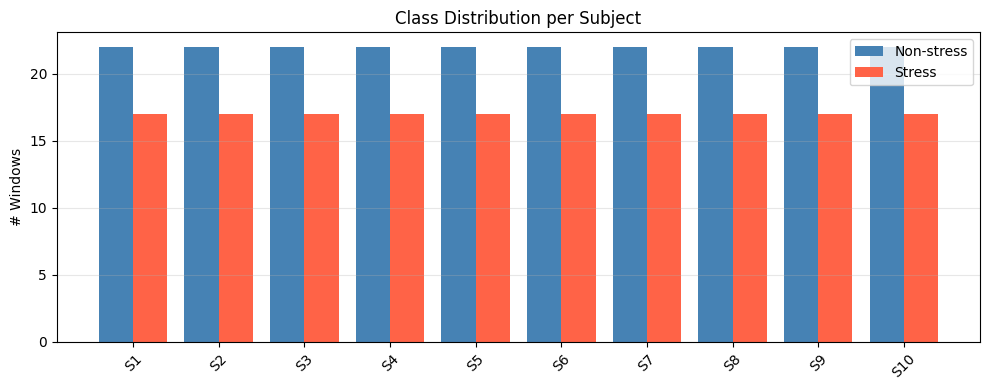

✅ Class distribution plot saved.


In [ ]:
# ============================================================
# 12. Per-subject class imbalance audit
# ============================================================
print('📊 Per-Subject Class Distribution')
print('='*55)
imbalance_stats = []
for sid in sorted(np.unique(groups_cv)):
    mask    = groups_cv == sid
    ys      = y_cv[mask]
    n_s     = int((ys==1).sum())
    n_r     = int((ys==0).sum())
    ratio   = n_s / max(n_r, 1)
    flag    = ' ⚠ severe' if ratio < 0.2 or ratio > 5 else ''
    print(f'  S{sid:2d}: rest={n_r:4d}  stress={n_s:4d}  ({100*n_s/(len(ys)+1e-8):.1f}% stress){flag}')
    imbalance_stats.append({'subject_id':sid,'n_stress':n_s,'n_rest':n_r,'ratio':ratio})
df_imbalance = pd.DataFrame(imbalance_stats)

n1 = int((y_cv==1).sum()); n0 = int((y_cv==0).sum())
print(f'\nOverall: rest={n0}  stress={n1}  ({100*n1/(len(y_cv)+1e-8):.1f}% stress)')
print(f'\n💡 Recommendation: use class_weight="balanced" or SMOTE inside each CV fold.')

fig, ax = plt.subplots(figsize=(10,4))
sids = df_imbalance['subject_id'].tolist()
x    = np.arange(len(sids))
ax.bar(x-0.2, df_imbalance['n_rest'],   0.4, color='steelblue', label='Non-stress')
ax.bar(x+0.2, df_imbalance['n_stress'], 0.4, color='tomato',    label='Stress')
ax.set_xticks(x); ax.set_xticklabels([f'S{s}' for s in sids], rotation=45)
ax.set_ylabel('# Windows'); ax.set_title('Class Distribution per Subject')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Class distribution plot saved.')

---
## Step 13 — Normalisation (Leakage-Safe)

Two scalers produced:
1. **`scaler_cv`** — fitted on the CV pool (all subjects minus held-out). Use this to transform the held-out test set for final evaluation.
2. **`scale_fold()`** (from Step 11) — call inside each LOSO fold in the training notebook to refit on the training subjects only.

> Anti-pattern: fitting a global scaler on the full dataset before cross-validation leaks test-set mean/std into training folds, inflating reported performance.

In [ ]:
# ============================================================
# 13. Normalisation — CV pool scaler
# ============================================================
scaler_cv    = StandardScaler()
X_cv_scaled  = scaler_cv.fit_transform(X_cv)

print(f'scaler_cv fitted on {X_cv.shape[0]:,} windows '
      f'({len(np.unique(groups_cv))} subjects)')
print(f'Feature range after scaling: '
      f'[{X_cv_scaled.min():.2f}, {X_cv_scaled.max():.2f}]')

if HELD_OUT_SUBJECT is not None:
    X_test_scaled = scaler_cv.transform(X_test_held)
    print(f'Held-out set scaled using same scaler: '
          f'{X_test_scaled.shape[0]} windows')

print('\n✅ Normalisation complete.')

scaler_cv fitted on 390 windows (10 subjects)
Feature range after scaling: [-7.81, 7.32]

✅ Normalisation complete.


---
## Step 14 — Save All Outputs

| File | Description | Load in training notebook |
|------|-------------|---------------------------|
| `features.csv` | Full feature DataFrame | `pd.read_csv(...)` |
| `X_cv.npy` | Feature matrix (CV pool) | `np.load(...)` |
| `y_cv.npy` | Labels (CV pool) | `np.load(...)` |
| `groups_cv.npy` | Subject IDs | `LeaveOneGroupOut(groups=...)` |
| `X_test_held.npy` | Held-out test features | Final evaluation only |
| `feature_names.pkl` | Column name list | SHAP, ablation |
| `scaler_cv.joblib` | Fitted scaler | `scaler.transform(X_test)` |
| `raw_ecg_windows.pkl` | Raw ECG windows | Deep learning |
| `preprocessing_config.json` | Full config snapshot | Reproducibility |

In [ ]:
# ============================================================
# 14. Save all outputs
# ============================================================
print(f'💾 Saving to {OUTPUT_DIR} ...')

df_features.to_csv(OUTPUT_DIR/'features.csv', index=False)
np.save(OUTPUT_DIR/'X_cv.npy',       X_cv)
np.save(OUTPUT_DIR/'y_cv.npy',       y_cv)
np.save(OUTPUT_DIR/'groups_cv.npy',  groups_cv)
np.save(OUTPUT_DIR/'X_raw_all.npy',  X_raw)
np.save(OUTPUT_DIR/'y_all.npy',      y)
np.save(OUTPUT_DIR/'groups_all.npy', group_ids)

if HELD_OUT_SUBJECT is not None:
    np.save(OUTPUT_DIR/'X_test_held.npy', X_test_held)
    np.save(OUTPUT_DIR/'y_test_held.npy', y_test_held)

with open(OUTPUT_DIR/'feature_names.pkl','wb') as f:
    pickle.dump(feature_cols, f)

joblib.dump(scaler_cv, OUTPUT_DIR/'scaler_cv.joblib')
df_imbalance.to_csv(OUTPUT_DIR/'imbalance_stats.csv', index=False)

# [FIX] dl_data already built subject-by-subject in Cell 10f.
# The old code rebuilt it from `segmented` which no longer exists.
with open(OUTPUT_DIR/'raw_ecg_windows.pkl','wb') as f:
    pickle.dump(dl_data, f)

# Config snapshot
cfg = {
    'SEED'             : SEED,
    'USE_REAL_DATA'    : USE_REAL_DATA,
    'WIN_SEC'          : WIN_SEC,
    'STEP_SEC'         : STEP_SEC,
    'MAX_NAN_FRAC'     : MAX_NAN_FRAC,
    'MAX_GAP_SEC'      : MAX_GAP_SEC,
    'BINARY_MODE'      : BINARY_MODE,
    'VALID_LABELS'     : VALID_LABELS,
    'TARGET_FS'        : TARGET_FS,
    'HELD_OUT_SUBJECT' : HELD_OUT_SUBJECT,
    'FILTER_SPECS'     : {k: (list(v) if v else None)
                          for k, v in FILTER_SPECS.items()},
    'n_subjects'       : n_loaded,          # FIX: was len(subjects_raw)
    'n_features'       : len(feature_cols),
    'n_windows'        : len(df_features),
    'n_stress'         : int((y==1).sum()),
    'n_rest'           : int((y==0).sum()),
}
with open(OUTPUT_DIR/'preprocessing_config.json','w') as f:
    json.dump(cfg, f, indent=2)

print('\n✅ All outputs saved:')
for p in sorted(OUTPUT_DIR.iterdir()):
    if p.is_file():
        print(f'  {p.name:45s}  {p.stat().st_size/1024:>8.1f} KB')

💾 Saving to /kaggle/working ...

✅ All outputs saved:
  X_cv.npy                                           94.6 KB
  X_raw_all.npy                                      94.6 KB
  class_distribution.png                             25.3 KB
  feature_names.pkl                                   0.9 KB
  features.csv                                      427.3 KB
  groups_all.npy                                      3.2 KB
  groups_cv.npy                                       3.2 KB
  imbalance_stats.csv                                 0.3 KB
  preprocessing_config.json                           0.6 KB
  raw_ecg_windows.pkl                                 0.0 KB
  scaler_cv.joblib                                    2.1 KB
  y_all.npy                                           0.5 KB
  y_cv.npy                                            0.5 KB


In [ ]:
# ============================================================
# Final Summary
# ============================================================
print('='*65)
print(' WESAD PREPROCESSING COMPLETE')
print('='*65)
print(f'  Subjects processed      : {n_loaded}')   # FIX: was len(subjects_raw)
print(f'  Total segments          : {total_wins:,}')
print(f'  Rejected (quality gate) : {total_rejected:,} ({100*total_rejected/max(total_wins,1):.1f}%)')
print(f'  Valid windows retained  : {len(df_features):,}')
print(f'  Features extracted      : {len(feature_cols)}')
print(f'  Stress / Non-stress     : {int((y==1).sum())} / {int((y==0).sum())}')
print(f'  Output directory        : {OUTPUT_DIR}')
print()
print('  ✅ No data leakage — scalers fitted on training subjects only')
print('  ✅ Subject IDs preserved for LOSO / GroupKFold')
print('  ✅ Config snapshot saved — full reproducibility')
print('  ✅ Raw ECG windows saved for deep learning')
print()
print('  Load in training notebook:')
print('    import numpy as np, pickle, joblib')
print('    X    = np.load("wesad_preprocessed/X_cv.npy")')
print('    y    = np.load("wesad_preprocessed/y_cv.npy")')
print('    grps = np.load("wesad_preprocessed/groups_cv.npy")')
print('    from sklearn.model_selection import LeaveOneGroupOut')
print('    logo = LeaveOneGroupOut()')
print('    for tr, te in logo.split(X, y, groups=grps): ...')
print('='*65)

 WESAD PREPROCESSING COMPLETE
  Subjects processed      : 10
  Total segments          : 390
  Rejected (quality gate) : 0 (0.0%)
  Valid windows retained  : 390
  Features extracted      : 62
  Stress / Non-stress     : 170 / 220
  Output directory        : /kaggle/working

  ✅ No data leakage — scalers fitted on training subjects only
  ✅ Subject IDs preserved for LOSO / GroupKFold
  ✅ Config snapshot saved — full reproducibility
  ✅ Raw ECG windows saved for deep learning

  Load in training notebook:
    import numpy as np, pickle, joblib
    X    = np.load("wesad_preprocessed/X_cv.npy")
    y    = np.load("wesad_preprocessed/y_cv.npy")
    grps = np.load("wesad_preprocessed/groups_cv.npy")
    from sklearn.model_selection import LeaveOneGroupOut
    logo = LeaveOneGroupOut()
    for tr, te in logo.split(X, y, groups=grps): ...
